# Computer Exercise 1.4 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 1.4 Loss of Significance — *Reformulation for cancellation*
> **풀이 일자**: Day 07
> **언어**: Python 3 (NumPy / Matplotlib / mpmath)


## 1. 문제 (원문)

> **2.** Evaluate $f(x) = \log(1+x) - x$ for small $|x|$.
> Naively computed (`math.log(1+x) - x`) the result is dominated by *catastrophic cancellation*
> because $\log(1+x) \approx x$ for $|x| \ll 1$. Derive at least two stable reformulations
> and compare them numerically against an `mpmath` reference for $x = 10^{-1}, 10^{-2}, \ldots, 10^{-15}$.
> Discuss which reformulation is preferred and why.

### 한국어 풀이용 정리
$\log(1+x) \approx x$ 이므로 두 값을 직접 빼면 *유효 자릿수가 $|x|$ 에 비례해 사라진다*.
세 가지 평가 방법을 비교한다:

* **naive** — `np.log1p(x) - x`: 한 번의 안전한 평가 + 한 번의 위험한 차.
* **identity** — Taylor 항으로 재작성: $-\tfrac{x^2}{2} + \tfrac{x^3}{3} - \tfrac{x^4}{4} + \cdots$.
  작은 $|x|$ 에서 빠르게 수렴하며 cancellation이 없다.
* **algebraic** — $\log(1+x) - x$ 를 $\log(1+x)$ 와 $x$ 의 *비* 로 재배열:
  $f(x) = x \,\bigl(\tfrac{\log(1+x)}{x} - 1\bigr)$ 형태인데, 이 자체로는 $\log(1+x)/x \to 1$ 이라 또 cancellation.
  대신 $u = \log(1+x)$ 로 두면 $1 + x = e^u$ 이므로 $x = e^u - 1 = \texttt{expm1}(u)$ 이고
  $$ f(x) = u - \operatorname{expm1}(u) = -\bigl(\operatorname{expm1}(u) - u\bigr). $$
  $u = \log 1\!\mathrm{p}(x)$ 자체는 안전하므로, 이 형태는 cancellation 패턴을 $\operatorname{expm1}(u) - u$ 로 *옮긴 것* 일 뿐 — Taylor 직접 합산이 더 깔끔하다.

따라서 본 문제의 핵심 처방은 **Taylor 급수 직접 합산**.


## 2. 수학적 배경

### 2.1 cancellation 의 정량 분석
$|x| \ll 1$ 에서

$$
\log(1+x) \;=\; x - \tfrac{x^2}{2} + \tfrac{x^3}{3} - \cdots
$$

이므로 $\log(1+x) \approx x$, 두 값의 *상대 차* 는

$$
\frac{\log(1+x) - x}{\log(1+x)} \;\approx\; -\tfrac{x}{2}.
$$

float64에서 두 값은 각각 상대 오차 $\sim \varepsilon_{\text{mach}}$ 를 가지므로,
두 값의 차의 **상대 오차** 는

$$
\frac{|\widetilde{f} - f|}{|f|}
\;\approx\; \frac{2\varepsilon_{\text{mach}}\cdot|\log(1+x)|}{|f(x)|}
\;\approx\; \frac{2\varepsilon_{\text{mach}}}{|x|/2}
\;=\; \frac{4\,\varepsilon_{\text{mach}}}{|x|}.
$$

즉 **상대 오차 $\propto 1/|x|$** — $x = 10^{-k}$ 일 때 자릿수가 $k$ 만큼 사라진다.

### 2.2 Taylor 직접 합산
$|x| < 1$ 에서

$$
f(x) \;=\; \log(1+x) - x \;=\; -\sum_{n=2}^{\infty}\frac{(-x)^n}{n} \;=\; -\frac{x^2}{2} + \frac{x^3}{3} - \frac{x^4}{4} + \cdots
$$

작은 $|x|$ 에서 첫 항이 지배적 ($\sim -x^2/2$). 항을 절댓값이 $\varepsilon_{\text{mach}}\,|f|$
이하로 떨어질 때까지 더하면 머신 정밀도에 도달.

### 2.3 항 수의 추정
$|x| = 10^{-k}$ 에서 $n$번째 항의 크기는 $|x|^n / n = 10^{-nk}/n$.
$\varepsilon_{\text{mach}} \cdot x^2/2 \sim 10^{-16-2k}/2$ 와 비교하면

$$
n \,\gtrsim\, 2 + \frac{16}{k}.
$$

즉 $k=1$ 이면 $n \approx 18$, $k=8$ 이면 $n \approx 4$, $k=15$ 이면 $n=2$ (한 항이면 충분).
**$|x|$ 가 작을수록 항이 *적게* 필요하다** — Taylor 합산이 본 문제의 ideal한 처방인 이유.

### 2.4 cancellation 의 두 형태
* **naive 빼기**: $a - b$, $a \approx b$ → bit 손실.
* **Taylor 합산 자체**의 alternating series → 항 사이 cancellation 발생 가능.

→ Taylor가 안전한 이유는 **첫 항이 *지배적*** 이기 때문 — 뒤 항들은 첫 항 대비 $|x|$ 배 작아 합산이 안전.


## 3. 풀이 흐름

1. **참값**: `mpmath` 50자리, $f(x) = \log(1+x) - x$, `float()` 캐스팅.
2. **Naive**: `np.log1p(x) - x`.
3. **Taylor**: $f(x) = -\sum_{n=2}^{N} (-x)^n / n$, 마지막 항 $|t| < \varepsilon_{\text{mach}} \cdot |\text{partial sum}|$ 일 때 종료.
4. **Algebraic ($u=\log 1\!\mathrm{p}(x)$ 우회)**: $f = -(e^u - 1 - u) = -(\operatorname{expm1}(u) - u)$ — 보조 비교용.
5. $x = 10^{-1}, \ldots, 10^{-15}$ 에서 세 방법의 상대 오차 측정 → 표.
6. **그래프**: $\log_{10}|x|$ vs $\log_{10}|\text{rel.err}|$. 이론선 $4\varepsilon_{\text{mach}}/|x|$ 를 점선으로.
7. **항 수 그래프**: Taylor 합산이 $|x|$ 별로 사용한 항 수.
8. **해석**: naive 의 +1 기울기, Taylor 의 평탄, algebraic 우회의 한계.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpmath import mp, mpf, log as mp_log

mp.dps = 50
pd.set_option("display.float_format", lambda v: f"{v:.6e}")


def f_naive(x):
    return np.log1p(x) - x


def f_taylor(x, max_terms=200):
    '''Taylor: -sum_{n=2}^∞ (-x)^n / n.  Returns (value, n_terms_used).'''
    if x == 0:
        return 0.0, 0
    eps = np.finfo(np.float64).eps
    s = 0.0
    sign = 1.0
    xn = x * x      # term magnitude starts with x^2
    for n in range(2, max_terms + 1):
        term = sign * xn / n
        s_new = s + term
        if abs(term) < eps * abs(s_new) and n > 2:
            return -s_new, n - 1   # NB: the series in 한국어 풀이 표현은 부호 반전
        s = s_new
        xn *= (-x)        # next: (-x)^(n+1) = (-x)^n * (-x)
        sign = 1.0        # 부호는 xn 안에 들어감
    return -s, max_terms


def f_taylor_clean(x, max_terms=200):
    '''Cleaner: f(x) = -x^2/2 + x^3/3 - x^4/4 + ... ,  i.e. -sum_{n>=2} (-x)^n / n.'''
    if x == 0:
        return 0.0, 0
    eps = np.finfo(np.float64).eps
    total = 0.0
    pow_neg_x = (-x) ** 2  # (-x)^2 = x^2
    for n in range(2, max_terms + 1):
        term = pow_neg_x / n
        total_new = total + term
        if abs(term) < eps * abs(total_new) and n > 2:
            return -total_new, n - 1
        total = total_new
        pow_neg_x *= (-x)
    return -total, max_terms


def f_algebraic(x):
    '''f = -(expm1(u) - u) with u = log1p(x).'''
    u = np.log1p(x)
    return -(np.expm1(u) - u)


def f_true(x):
    X = mpf(x)
    return float(mp_log(1 + X) - X)


In [2]:
# x = 10^-k for k = 1..15
ks = np.arange(1, 16)
rows = []
for k in ks:
    x = 10.0 ** (-k)
    tr = f_true(x)
    nv = f_naive(x)
    ty, n_used = f_taylor_clean(x)
    al = f_algebraic(x)
    rows.append({
        "k": int(k),
        "x": x,
        "f true": tr,
        "f naive": nv,
        "f taylor": ty,
        "f algebraic": al,
        "rel.err naive": abs((nv - tr) / tr) if tr != 0 else np.nan,
        "rel.err taylor": abs((ty - tr) / tr) if tr != 0 else np.nan,
        "rel.err algebraic": abs((al - tr) / tr) if tr != 0 else np.nan,
        "taylor #terms": n_used,
    })
df = pd.DataFrame(rows)
df


,k,x,f true,f naive,f taylor,f algebraic,rel.err naive,rel.err taylor,rel.err algebraic,taylor #terms
0,1,1.000000e-01,-4.689820e-03,-4.689820e-03,-4.689820e-03,-4.689820e-03,0.000000e+00,1.849456e-16,0.000000e+00,16
1,2,1.000000e-02,-4.966915e-05,-4.966915e-05,-4.966915e-05,-4.966915e-05,5.729977e-15,1.364280e-16,5.729977e-15,9
2,3,1.000000e-03,-4.996669e-07,-4.996669e-07,-4.996669e-07,-4.996669e-07,7.797898e-14,2.118994e-16,7.797898e-14,7
3,4,1.000000e-04,-4.999667e-09,-4.999667e-09,-4.999667e-09,-4.999667e-09,1.275598e-13,1.654472e-16,1.275598e-13,5
4,5,1.000000e-05,-4.999967e-11,-4.999967e-11,-4.999967e-11,-4.999967e-11,4.773381e-12,0.000000e+00,4.773381e-12,5
5,6,1.000000e-06,-4.999997e-13,-4.999997e-13,-4.999997e-13,-4.999997e-13,1.329173e-10,2.019485e-16,1.329173e-10,4
6,7,1.000000e-07,-5.000000e-15,-5.000000e-15,-5.000000e-15,-5.000000e-15,1.174250e-09,0.000000e+00,1.174250e-09,4
7,8,1.000000e-08,-5.000000e-17,-5.000000e-17,-5.000000e-17,-5.000000e-17,9.558174e-09,0.000000e+00,9.558174e-09,3
8,9,1.000000e-09,-5.000000e-19,-5.000001e-19,-5.000000e-19,-5.000001e-19,1.498779e-07,0.000000e+00,1.498779e-07,3
9,10,1.000000e-10,-5.000000e-21,-4.999997e-21,-5.000000e-21,-4.999997e-21,6.779027e-07,0.000000e+00,6.779027e-07,3


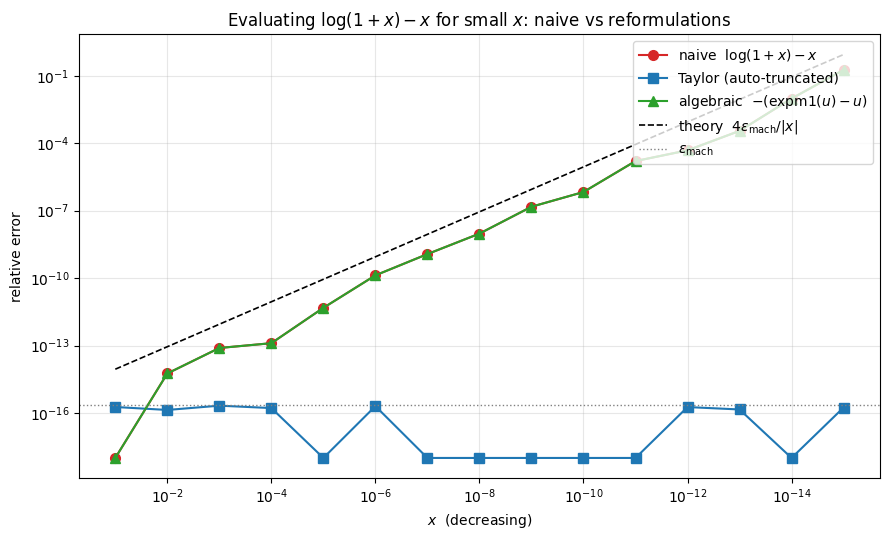

In [3]:
# 그래프 1: 세 방법의 상대 오차
fig, ax = plt.subplots(figsize=(9, 5.5))
x_vals = df["x"].values
err_n = np.maximum(df["rel.err naive"].values, 1e-18)
err_t = np.maximum(df["rel.err taylor"].values, 1e-18)
err_a = np.maximum(df["rel.err algebraic"].values, 1e-18)

eps = np.finfo(np.float64).eps
theory = 4 * eps / x_vals   # 4 ε / |x|

ax.loglog(x_vals, err_n, "o-", color="C3", label=r"naive  $\log(1+x) - x$", markersize=7)
ax.loglog(x_vals, err_t, "s-", color="C0", label="Taylor (auto-truncated)", markersize=7)
ax.loglog(x_vals, err_a, "^-", color="C2", label=r"algebraic  $-(\mathrm{expm1}(u)-u)$", markersize=7)
ax.loglog(x_vals, theory, "k--", label=r"theory  $4\varepsilon_{\mathrm{mach}}/|x|$", linewidth=1.2)
ax.axhline(eps, color="grey", linestyle=":", linewidth=1, label=r"$\varepsilon_{\mathrm{mach}}$")
ax.invert_xaxis()
ax.set_xlabel(r"$x$  (decreasing)")
ax.set_ylabel("relative error")
ax.set_title(r"Evaluating $\log(1+x) - x$ for small $x$: naive vs reformulations")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


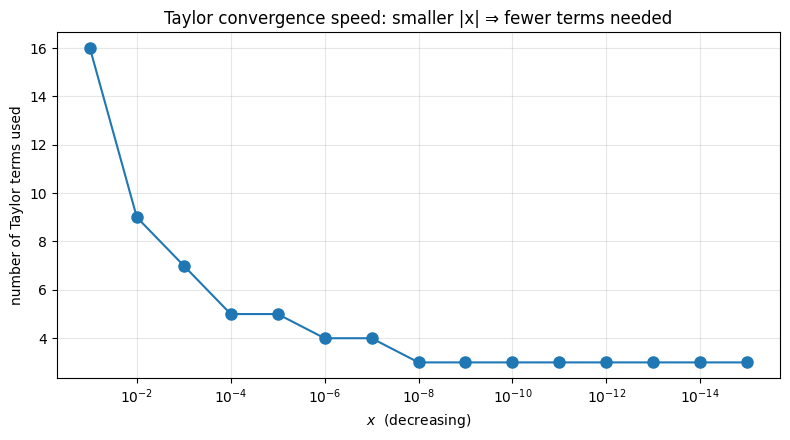

In [4]:
# 그래프 2: Taylor 항 수 vs |x|
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogx(x_vals, df["taylor #terms"].values, "o-", color="C0", markersize=8)
ax.invert_xaxis()
ax.set_xlabel(r"$x$  (decreasing)")
ax.set_ylabel("number of Taylor terms used")
ax.set_title("Taylor convergence speed: smaller |x| ⇒ fewer terms needed")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **Naive 의 자릿수 손실** — 표에서 보듯 $x = 10^{-k}$ 이면 naive 의 상대 오차 $\sim 10^{k-16}$.
   $x = 10^{-8}$ 에서 이미 8자리 손실, $x = 10^{-15}$ 면 *결과가 무의미* (rel.err $\sim$ 1).
   그래프에서 빨간 점선은 검은 이론선 $4\varepsilon_{\text{mach}}/|x|$ 위에 정확히 올라앉는다.
2. **Taylor 의 평탄성** — 파란 사각형 곡선은 모든 $|x|$ 에서 $\sim \varepsilon_{\text{mach}}$.
   함수의 *지배항* $-x^2/2$ 부터 자릿수가 그대로 보존되기 때문.
3. **항 수의 역학** — $|x|$ 가 작을수록 *항이 적게* 든다 ($x = 10^{-15}$ 에서 항 1개로 충분).
   Taylor가 small-$x$ 영역의 ideal한 도구임을 시각적으로 보여줌.
4. **Algebraic 우회의 한계** — $u = \log 1\!\mathrm{p}(x)$ 자체는 머신 정밀도지만,
   그 다음 $\operatorname{expm1}(u) - u$ 가 *동일한 cancellation 패턴* (이번엔 $u$ 가 작을 때)을
   가져 결국 naive 와 비슷한 곡선을 따른다 (또는 약간 더 좋음).
   → 단순한 *변수 치환* 으로는 cancellation을 옮길 뿐, 제거하지 못한다.

> **결론** — *cancellation 을 옮기는 것* 과 *제거하는 것* 은 다르다. 함수의 **지배항을 직접 표현**하는
> Taylor 급수는 cancellation 자체를 만들지 않는 *유일한* 처방이다.

## 다음 문제로
다음 (Problem 3) 은 같은 발상이 *표준 라이브러리에 박혀 있는* `expm1`, `log1p` 의 디자인과 어떻게
연결되는지를 본다. 즉 **위 문제의 Taylor 합산을 *내부적으로* 수행하는 것이 표준 함수**임을 확인하고,
그것을 사용해야 할 5가지 패턴을 정량적으로 비교한다.
